## Parte 1: Importación de datos

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import geemap,ee
import os

In [2]:
ee.Authenticate()
ee.Initialize(project='ee-benja3525')

C:\Users\benji\AppData\Local\Temp\ipykernel_14968\3308869618.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ys = ys.unary_union


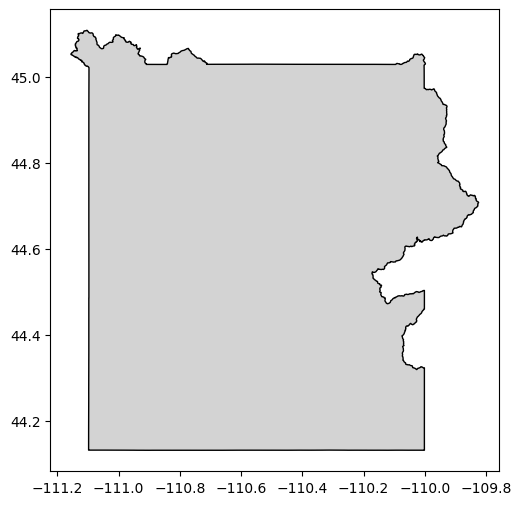

In [3]:
ys = gpd.read_file('YELL_tracts/YELL_tracts.shp')
ys = ys.to_crs('EPSG:4326')
ys = ys.unary_union
ys = gpd.GeoDataFrame(geometry=[ys], crs='EPSG:4326')
aoi = geemap.gdf_to_ee(ys)

centro = [44.952205, -110.496154]

fig, ax = plt.subplots(figsize=(6, 6))
ys.plot(ax=ax, edgecolor='black', facecolor='lightgray')
plt.show()

In [ ]:
#visualización: https://www.usgs.gov/centers/eros/science/annual-national-land-cover-database

nlcd_vis = {
    'min': 0,
    'max': 95,
    'palette': [
        '466b9f',  # Open Water (11)
        'd1def8',  # Developed, Open Space (21)
        'dec5c5',  # Developed, Low Intensity (22)
        'd99282',  # Developed, Medium Intensity (23)
        'eb0000',  # Developed, High Intensity (24)
        'ab0000',  # Barren Land (31)
        'ba2dba',  # Deciduous Forest (41) #LO QUE QUEREMOS: BOSQUE CADUCIFOLIO
        '68ab5f',  # Evergreen Forest (42)
        '1c5f2c',  # Mixed Forest (43)
        'b5ca8f',  # Shrub/Scrub (52)
        'a2ff00',  # Grassland/Herbaceous (71)
        'f0e442',  # Pasture/Hay (81)
        '006400',  # Cultivated Crops (82)
        'c8e6c9',  # Woody Wetlands (90)
        '9de0ad'   # Emergent Herbaceous Wetlands (95)
    ]
}

nlcd_labels = [
    "Open Water", "Developed, Open Space", "Developed, Low Intensity", 
    "Developed, Medium Intensity", "Developed, High Intensity",
    "Barren Land", "Deciduous Forest", "Evergreen Forest", 
    "Mixed Forest", "Shrub/Scrub", "Grassland/Herbaceous", 
    "Pasture/Hay", "Cultivated Crops", "Woody Wetlands", 
    "Emergent Herbaceous Wetlands"
]

nlcd_colors = [
    '#466b9f', '#d1def8', '#dec5c5', '#d99282', '#eb0000',
    '#ab0000', '#ba2dba', '#68ab5f', '#1c5f2c', '#b5ca8f',
    '#a2ff00', '#f0e442', '#006400', '#c8e6c9', '#9de0ad'
]

## Parte 2: Obtención de NLCD (National Land Cover Databases)

In [ ]:
# 2001, 2011: https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2019_REL_NLCD?hl=es-419
# 2021: https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2021_REL_NLCD?hl=es-419


nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
lc_2001 = nlcd.filter(ee.Filter.eq('system:index', '2001')).first().select('landcover').clip(aoi)
lc_2011 = nlcd.filter(ee.Filter.eq('system:index', '2011')).first().select('landcover').clip(aoi)

lc_2021 = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD").filter(ee.Filter.eq('system:index', '2021')).first().select('landcover').clip(aoi)

## Parte 3: Predicción de uso del suelo

In [ ]:
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(aoi) \
    .filterDate('2020-06-01', '2020-09-01') \
    .median() \
    .select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'])

training_points = lc_2021.addBands(landsat).sample(
    region=aoi.geometry(),
    scale=30,
    numPixels=5000,
    seed=42,
    geometries=True
)

classifier = ee.Classifier.smileRandomForest(50).train(
    features=training_points,
    classProperty='landcover',
    inputProperties=['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
)

prediction = landsat.classify(classifier).clip(aoi)


In [ ]:
Map = geemap.Map(center=centro, zoom=10)
Map.addLayer(lc_2001, nlcd_vis, "NLCD 2001", shown=False)
Map.addLayer(lc_2011, nlcd_vis, "NLCD 2011", shown=False)
Map.addLayer(lc_2021, nlcd_vis, "NLCD 2021", shown=False)
Map.addLayer(prediction, nlcd_vis, "Predicción", shown=True)
Map.addLayer(aoi, {}, 'aoi', shown=False)
Map.add_legend(title="NLCD Land Cover", labels=nlcd_labels, colors=nlcd_colors)
Map

Map(center=[44.952205, -110.496154], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Se…

In [ ]:
# geemap.ee_export_image(
#     landsat,
#     filename='landsat_2020.tif',
#     scale=135,
#     region=aoi.geometry(),
#     file_per_band=True
# )

# geemap.ee_export_image(
#     lc_2001,
#     filename='nlcd_2001_mask.tif',
#     scale=30,
#     region=aoi.geometry(),
#     file_per_band=False
# )

# geemap.ee_export_image(
#     lc_2011,
#     filename='nlcd_2011_mask.tif',
#     scale=30,
#     region=aoi.geometry(),
#     file_per_band=False
# )


# geemap.ee_export_image(
#     lc_2021,
#     filename='nlcd_2021_mask.tif',
#     scale=30,
#     region=aoi.geometry(),
#     file_per_band=False
# )


In [ ]:
import os
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np

class LandCoverDataset(Dataset):
    def __init__(self, image_dir, mask_path, transform=None):
        self.image_dir = image_dir
        self.mask_path = mask_path
        self.transform = transform
        self.band_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif')])
        self.image_paths = [os.path.join(image_dir, f) for f in self.band_files]

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        bands = [rasterio.open(p).read(1) for p in self.image_paths]
        image = np.stack(bands, axis=0).astype(np.float32) / 10000.0  #normalizar

        with rasterio.open(self.mask_path) as msk:
            mask = msk.read(1).astype(np.int64)
        # mask[mask > 95] = 0

        return torch.tensor(image), torch.tensor(mask)

In [ ]:
dataset = LandCoverDataset(
    image_dir='images/',
    mask_path='masks/nlcd_2021_mask.tif'
)

image, mask = dataset[0]
print("Shape de imagen:", image.shape)  # (6, H, W)
print("Shape de máscara:", mask.shape)  # (H, W)


Shape de imagen: torch.Size([6, 806, 1099])
Shape de máscara: torch.Size([4027, 3659])


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])

dataset = LandCoverDataset(
    image_dir='images/',
    mask_path='masks/nlcd_2021_mask.tif',
    transform=transform
)

image, mask = dataset[0]


In [ ]:
import segmentation_models_pytorch as smp

n_classes = int(mask.max().item() + 1)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=6, # Landsat tiene 6 bandas
    classes=n_classes
)

In [ ]:
import torch
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

loader = DataLoader(dataset, batch_size=1, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

model.train()
for epoch in range(5):
    for img, msk in loader:
        img, msk = img.to(device), msk.to(device)
        optimizer.zero_grad()
        logits = model(img)
        loss = loss_fn(logits, msk)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 5658160512 bytes.

In [ ]:
model.eval()
with torch.no_grad():
    pred_logits = model(image.unsqueeze(0).to(device))
    pred_mask = torch.argmax(pred_logits.squeeze(), dim=0).cpu().numpy()


## Parte 4: Simulación para 2031

In [ ]:
# def visualize_nlcd(img):
#     vis = img.visualize(**nlcd_vis)
#     return vis.clip(aoi)

# rgb_2001 = visualize_nlcd(lc_2001)
# rgb_2011 = visualize_nlcd(lc_2011)
# rgb_2021 = visualize_nlcd(lc_2021)

## Predicción con NDVI

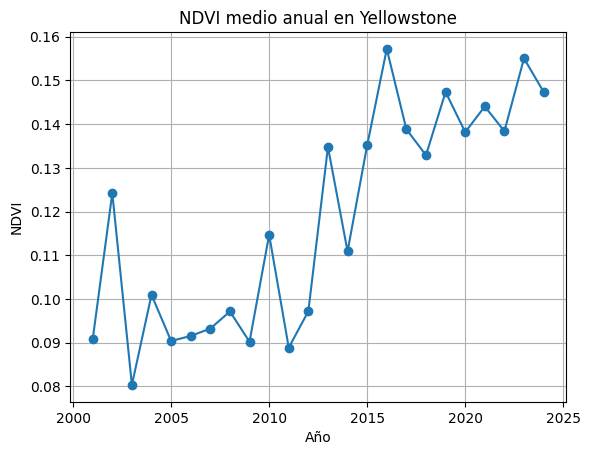

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import rasterio

folder = 'ndvi_anual'
years = list(range(2001, 2025))
ndvi_means = []

for y in years:
    path = f"{folder}/{y}_NDVI_MNDWI.tif"
    with rasterio.open(path) as src:
        ndvi = src.read(1)
        ndvi[ndvi == src.nodata] = np.nan 
        ndvi_means.append(np.nanmean(ndvi))

plt.plot(years, ndvi_means, marker='o')
plt.title("NDVI medio anual en Yellowstone")
plt.xlabel("Año")
plt.ylabel("NDVI")
plt.grid(True)
plt.show()


20:16:07 - cmdstanpy - INFO - Chain [1] start processing
20:16:09 - cmdstanpy - INFO - Chain [1] done processing


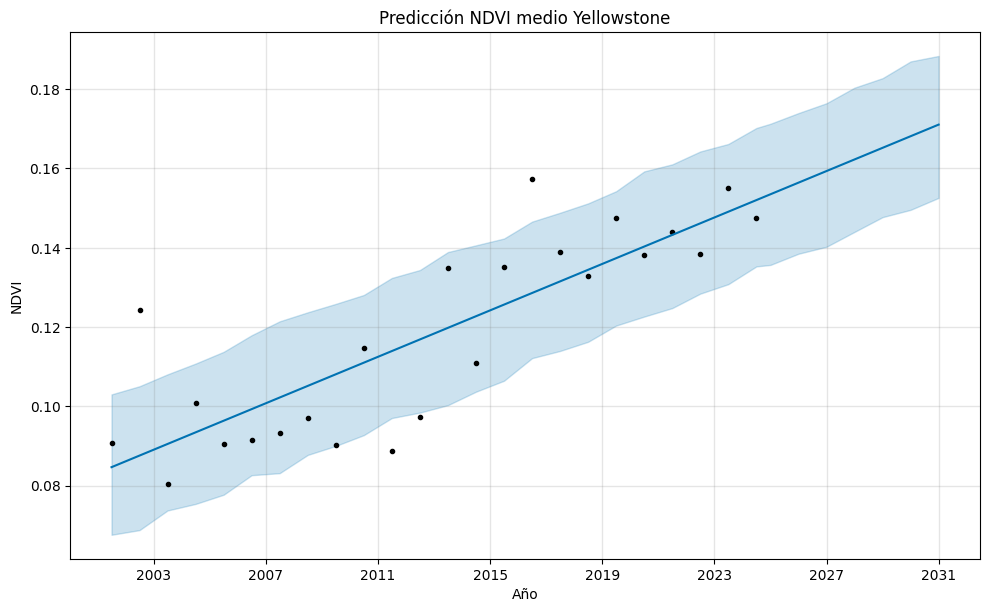

In [ ]:
import pandas as pd
from prophet import Prophet

df = pd.DataFrame({'ds': pd.to_datetime([f"{y}-07-01" for y in years]),
                   'y': ndvi_means})

model = Prophet(yearly_seasonality=False)
model.fit(df)

future = model.make_future_dataframe(periods=7, freq='Y')  # 2025-2031
forecast = model.predict(future)

model.plot(forecast)
plt.title("Predicción NDVI medio Yellowstone")
plt.xlabel("Año")
plt.ylabel("NDVI")
plt.grid(True)
plt.show()


In [ ]:
import rasterio
import numpy as np
import os

folder = 'ndvi_anual'
years = list(range(2001, 2025))
ndvi_stack = []

for y in years:
    path = os.path.join(folder, f"{y}_NDVI_MNDWI.tif")
    with rasterio.open(path) as src:
        ndvi = src.read(1) #Banda 1: NDVI
        ndvi[ndvi == src.nodata] = np.nan
        ndvi_stack.append(ndvi)

ndvi_array = np.stack(ndvi_stack, axis=0)  # (años, filas, columnas)


In [ ]:
from sklearn.linear_model import LinearRegression

n_years, n_rows, n_cols = ndvi_array.shape
X = np.array(years).reshape(-1, 1)

ndvi_flat = ndvi_array.reshape(n_years, -1).T  # shape: (n_pixeles, n_years)

# Máscara para píxeles válidos (sin NaN)
mask = ~np.isnan(ndvi_flat).any(axis=1)

models = LinearRegression().fit(X, ndvi_flat[mask].T)


# Predicción para 2025
ndvi_2025_flat = np.full(ndvi_flat.shape[0], np.nan)
ndvi_2025_flat[mask] = models.predict([[2025]])

ndvi_2025 = ndvi_2025_flat.reshape(n_rows, n_cols)

In [ ]:
with rasterio.open(os.path.join(folder, f"{years[-1]}_NDVI_MNDWI.tif")) as src:
    profile = src.profile

profile.update(dtype=rasterio.float32, count=1)

with rasterio.open("NDVI_2025_pred.tif", "w", **profile) as dst:
    dst.write(ndvi_2025.astype(np.float32), 1)
